In [1]:
#group 3 question7
#Ankit Yadav (2025mem1047)
#Nitin Kumar(2025mem1051)
#importing libraries
import warnings
warnings.filterwarnings('ignore')

import zipfile
import io
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight


In [2]:

SEED = 42

BATCH = 64 #model will process 64 samples at once for updating weights

EPOCHS = 100

ZIP_PATH = 'DL_data.zip'

# Random seed

np.random.seed(SEED)

torch.manual_seed(SEED)

# GPU check

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #GPU is much faster for matrix operations and other NN operations

print("PyTorch Version :", torch.__version__)

print("Using Device :", DEVICE)

PyTorch Version : 2.2.2+cpu
Using Device : cpu


In [4]:
# Loading the dataset

print("Loading dataset...")

z = zipfile.ZipFile(ZIP_PATH)

names = z.namelist() #it will gives all filenames inside the zip file

# Load thickness data

with z.open('prob1_data/output.xlsx') as f:

    X_raw = pd.read_excel(io.BytesIO(f.read())).values.astype(np.float32)

print("Input Shape :", X_raw.shape)

# Load stress files ,Files will be sorted

stress_files = sorted(
    [n for n in names if 'prob1_data/stress/' in n and n.endswith('.txt')],
    key=lambda x: int(x.split('_')[-1].replace('.txt', ''))
)

max_stress = np.zeros(len(stress_files), dtype=np.float32)

for i, sf in enumerate(stress_files):

    with z.open(sf) as f:

        data = np.loadtxt(io.StringIO(f.read().decode()))

    max_stress[i] = data[:,0].max() #this will give stress array

print("Dataset Loaded Successfully") 

Loading dataset...
Input Shape : (5000, 226)
Dataset Loaded Successfully


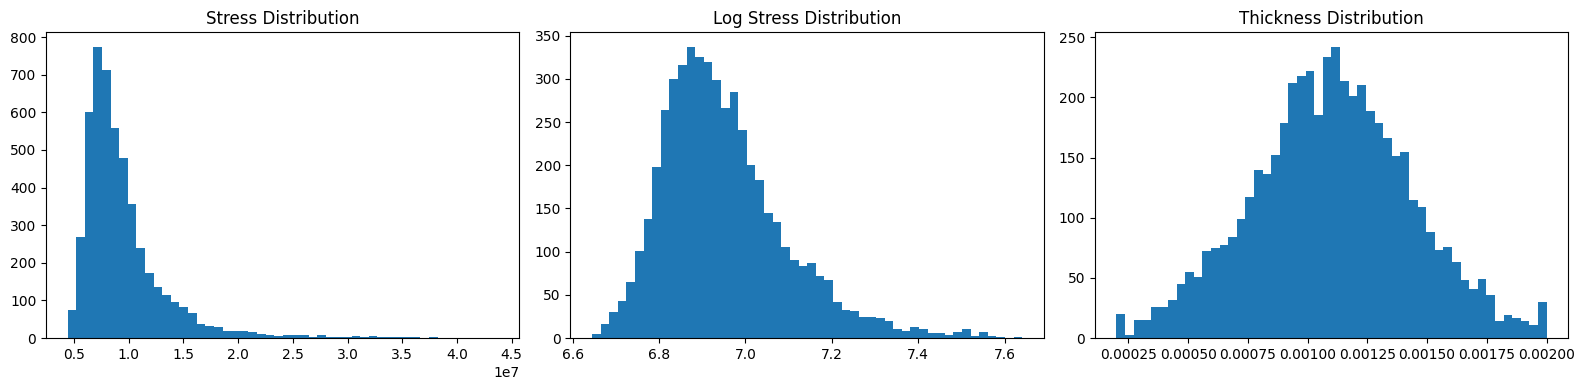

In [5]:
# different type of data visulaization
fig, axes = plt.subplots(1,3, figsize=(16,4))

# Stress distribution

axes[0].hist(max_stress, bins=50)

axes[0].set_title("Stress Distribution")

# Log stress

axes[1].hist(np.log10(max_stress), bins=50)

axes[1].set_title("Log Stress Distribution")

# Thickness distribution

axes[2].hist(X_raw[:,0], bins=50)

axes[2].set_title("Thickness Distribution")

plt.tight_layout()

plt.show()

In [6]:
# Train test split

X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(
    X_raw,
    max_stress,
    test_size=0.30,
    random_state=SEED
)

X_val, X_test, y_val_reg, y_test_reg = train_test_split(
    X_temp,
    y_temp_reg,
    test_size=0.50,
    random_state=SEED
)

print("Train :", len(X_train))

print("Validation :", len(X_val))

print("Test :", len(X_test))

Train : 3500
Validation : 750
Test : 750


In [8]:
# feature scaling (it helpss in fater convergence because features might be of different scales we need to convert in standard scales)
scaler_X = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train).astype(np.float32)

X_val_s = scaler_X.transform(X_val).astype(np.float32)

X_test_s = scaler_X.transform(X_test).astype(np.float32)

In [9]:
# appying log transform inorder to reduce the effect of large values
y_train_log = np.log(y_train_reg)

mu_y = y_train_log.mean()

sigma_y = y_train_log.std()

y_train_norm = ((y_train_log - mu_y)/sigma_y).astype(np.float32)

y_val_norm = ((np.log(y_val_reg)-mu_y)/sigma_y).astype(np.float32)

y_test_norm = ((np.log(y_test_reg)-mu_y)/sigma_y).astype(np.float32)

In [12]:
# creating class lables (making it a classification )

def make_labels(y_values, thresholds):

    labels = np.zeros(len(y_values), dtype=np.int64)

    labels[y_values <= thresholds[0]] = 0

    labels[(y_values > thresholds[0]) & (y_values <= thresholds[1])] = 1

    labels[(y_values > thresholds[1]) & (y_values <= thresholds[2])] = 2

    labels[y_values > thresholds[2]] = 3

    return labels

p10, p25, p50 = np.percentile(y_train_reg, [10,25,50]) #percentile lable ,what percentage of data lies below a given value

y_train_cls = make_labels(y_train_reg, [p10,p25,p50])

y_val_cls = make_labels(y_val_reg, [p10,p25,p50])

y_test_cls = make_labels(y_test_reg, [p10,p25,p50])

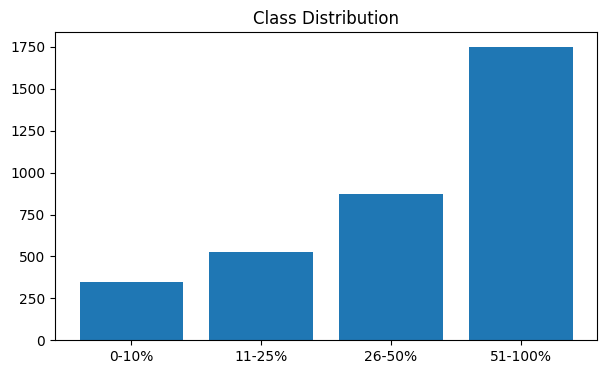

In [13]:
# class distribution

class_names = ['0-10%', '11-25%', '26-50%', '51-100%'] #lables  for four classes

unique, counts = np.unique(y_train_cls, return_counts=True)

plt.figure(figsize=(7,4))

plt.bar(class_names, counts)

plt.title("Class Distribution")

plt.show()

In [14]:
# CNN network
class CNNBackbone(nn.Module): #creating a custom neural network class

    def __init__(self): #intialization of network ,inside this we will create layers and define our architecture

        super().__init__() #calling pytorch class constructor
        #below layers will be executed in layers

        self.conv_layers = nn.Sequential(

            nn.Conv1d(1,64,kernel_size=5,padding=2), #using 1d sequencial data(we have only thickness profile,5 kernels for 5 neighbouring values)

            nn.BatchNorm1d(64), #normalizaing the output

            nn.ReLU(), #activation function(without activation NN will become linear)

            nn.MaxPool1d(2),

            nn.Conv1d(64,128,kernel_size=3,padding=1),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(128,256,kernel_size=3,padding=1),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),#to reshape data

            nn.Linear(256,256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256,128), #for feature reduction

            nn.ReLU(),

            nn.Dropout(0.3) #for regularization
        )

    def forward(self, x):

        # Convert shape from (N,226) to (N,1,226) adds one extra dimension because CNN understand the data in this form

        x = x.unsqueeze(1)

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x







In [15]:
# Regression CNN(model for stress predcition)

class RegressionCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = CNNBackbone() #learns pattern from thickness data

        self.head = nn.Linear(128,1) #final prediction layer (converrts 128 features into 1 stress value)

    def forward(self,x):

        return self.head(self.backbone(x)).squeeze(1) 



In [16]:
# CNN model for classification, instead of stress values it will predicts low,medium and high stress
class ClassificationCNN(nn.Module):

    def __init__(self, n_classes=4):# 4 percentile ranges

        super().__init__()

        self.backbone = CNNBackbone()

        self.head = nn.Linear(128,n_classes)

    def forward(self,x):

        return self.head(self.backbone(x))

In [17]:
# creating dataloader,creating batches for training instead of giving all the data at once

def make_loader(X, y, batch_size=64, shuffle=True):

    X_t = torch.tensor(X, dtype=torch.float32)

    y_t = torch.tensor(y)

    dataset = TensorDataset(X_t, y_t)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return loader

In [32]:
# Training functtion
def train_model(model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                epochs=100):

    train_losses = [] #store training loss

    val_losses = [] #store validation loss

    for epoch in range(epochs):

        # Training

        model.train()

        running_loss = 0

        for X_b, y_b in train_loader:

            X_b = X_b.to(DEVICE)

            y_b = y_b.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(X_b)

            loss = criterion(outputs, y_b)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss)

        # Validation

        model.eval()

        val_loss = 0

        with torch.no_grad():

            for X_b, y_b in val_loader:

                X_b = X_b.to(DEVICE)

                y_b = y_b.to(DEVICE)

                outputs = model(X_b)

                loss = criterion(outputs, y_b)

                val_loss += loss.item()

        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train Loss : {running_loss:.4f} | Validation Loss : {val_loss:.4f}")

    return train_losses, val_losses


In [19]:
print("\nTraining Regression CNN ...")

train_loader_reg = make_loader(
    X_train_s,
    y_train_norm,
    BATCH
)

val_loader_reg = make_loader(
    X_val_s,
    y_val_norm,
    BATCH,
    shuffle=False
)

# Create model

model_reg = RegressionCNN().to(DEVICE)

# Optimizer

optimizer_reg = optim.Adam(model_reg.parameters(), lr=1e-3)

# Loss function

criterion_reg = nn.MSELoss()

# Train model

train_loss_reg, val_loss_reg = train_model(
    
    model_reg,
    
    train_loader_reg,
    
    val_loader_reg,
    
    criterion_reg,
    
    optimizer_reg,
    
    EPOCHS
)


Training Regression CNN ...
Epoch 1 | Train Loss : 47.6744 | Validation Loss : 8.0753
Epoch 2 | Train Loss : 45.9144 | Validation Loss : 9.6473
Epoch 3 | Train Loss : 40.5860 | Validation Loss : 6.8156
Epoch 4 | Train Loss : 30.6333 | Validation Loss : 4.7433
Epoch 5 | Train Loss : 27.7545 | Validation Loss : 7.8481
Epoch 6 | Train Loss : 24.2642 | Validation Loss : 4.0248
Epoch 7 | Train Loss : 23.1766 | Validation Loss : 4.7209
Epoch 8 | Train Loss : 22.9643 | Validation Loss : 4.9180
Epoch 9 | Train Loss : 22.3946 | Validation Loss : 4.2004
Epoch 10 | Train Loss : 20.9297 | Validation Loss : 4.6752
Epoch 11 | Train Loss : 20.0701 | Validation Loss : 23.3444
Epoch 12 | Train Loss : 20.7778 | Validation Loss : 11.1602
Epoch 13 | Train Loss : 18.9386 | Validation Loss : 4.2024
Epoch 14 | Train Loss : 18.9358 | Validation Loss : 6.0685
Epoch 15 | Train Loss : 18.6400 | Validation Loss : 4.8252
Epoch 16 | Train Loss : 18.1863 | Validation Loss : 9.1658
Epoch 17 | Train Loss : 16.0471 | 

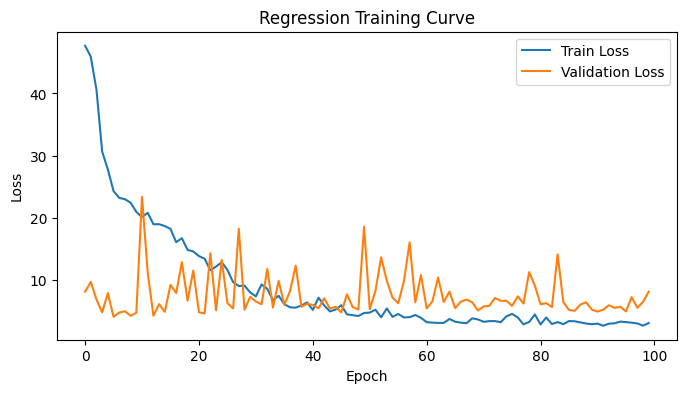

In [20]:
# Regression loss plot
plt.figure(figsize=(8,4))

plt.plot(train_loss_reg, label='Train Loss')

plt.plot(val_loss_reg, label='Validation Loss')

plt.title("Regression Training Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [21]:
# REGRESSION TESTING
model_reg.eval()

with torch.no_grad():

    y_pred_norm = model_reg(
        torch.tensor(X_test_s).to(DEVICE)
    ).cpu().numpy()

# Convert back to original scale

y_pred_orig = np.exp(y_pred_norm*sigma_y + mu_y)

# Metrics

mse = mean_squared_error(y_test_reg, y_pred_orig)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test_reg, y_pred_orig)

r2 = r2_score(y_test_reg, y_pred_orig)

print("\nRegression Results")

print("R2 Score :", r2)

print("RMSE :", rmse)

print("MAE :", mae)





Regression Results
R2 Score : 0.3589785695075989
RMSE : 2956389.8839388555
MAE : 2106605.5


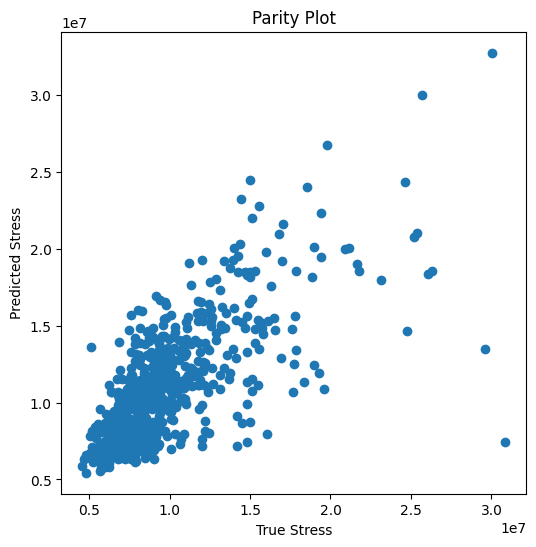

In [22]:
# parity plot

plt.figure(figsize=(6,6))

plt.scatter(y_test_reg, y_pred_orig)

plt.xlabel("True Stress")

plt.ylabel("Predicted Stress")

plt.title("Parity Plot")

plt.show()


Training Classification CNN ...
Epoch 1 | Train Loss : 70.9770 | Validation Loss : 14.9358
Epoch 2 | Train Loss : 69.8121 | Validation Loss : 17.4937
Epoch 3 | Train Loss : 68.5520 | Validation Loss : 15.1394
Epoch 4 | Train Loss : 66.8795 | Validation Loss : 21.8987
Epoch 5 | Train Loss : 62.9688 | Validation Loss : 13.3753
Epoch 6 | Train Loss : 57.8755 | Validation Loss : 13.1320
Epoch 7 | Train Loss : 56.5223 | Validation Loss : 20.3383
Epoch 8 | Train Loss : 55.7269 | Validation Loss : 19.3736
Epoch 9 | Train Loss : 51.4569 | Validation Loss : 11.7097
Epoch 10 | Train Loss : 51.2601 | Validation Loss : 12.4412
Epoch 11 | Train Loss : 49.8619 | Validation Loss : 29.6924
Epoch 12 | Train Loss : 48.9426 | Validation Loss : 13.0021
Epoch 13 | Train Loss : 48.0642 | Validation Loss : 12.5500
Epoch 14 | Train Loss : 45.9304 | Validation Loss : 20.9932
Epoch 15 | Train Loss : 43.4905 | Validation Loss : 24.7136
Epoch 16 | Train Loss : 43.6783 | Validation Loss : 17.5853
Epoch 17 | Train

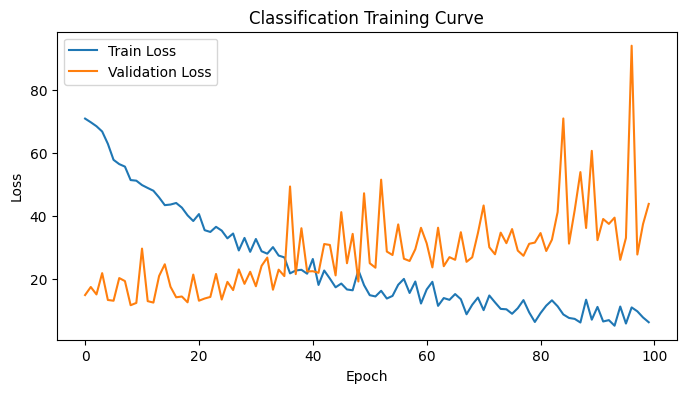

In [23]:
# Classification approach ,predicting stress classes
print("\nTraining Classification CNN ...")

# Class weights for imbalance handling, without balancing model becomes biased towards majority class

cw = compute_class_weight(
    
    'balanced',
    
    classes=np.array([0,1,2,3]),
    
    y=y_train_cls
)

class_weights_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

# Data loaders

train_loader_cls = make_loader(
    X_train_s,
    y_train_cls,
    BATCH
)

val_loader_cls = make_loader(
    X_val_s,
    y_val_cls,
    BATCH,
    shuffle=False
)

# Create model

model_cls = ClassificationCNN().to(DEVICE)

# Optimizer

optimizer_cls = optim.Adam(model_cls.parameters(), lr=1e-3)

# Loss function

criterion_cls = nn.CrossEntropyLoss(weight=class_weights_tensor) #used for multi class classification

# Train model

train_loss_cls, val_loss_cls = train_model(
    
    model_cls,
    
    train_loader_cls,
    
    val_loader_cls,
    
    criterion_cls,
    
    optimizer_cls,
    
    EPOCHS
)

# Classification loss plots

plt.figure(figsize=(8,4))

plt.plot(train_loss_cls, label='Train Loss')

plt.plot(val_loss_cls, label='Validation Loss')

plt.title("Classification Training Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()



In [24]:
# Classification testing

model_cls.eval()

with torch.no_grad():

    logits = model_cls(
        torch.tensor(X_test_s).to(DEVICE)
    )

y_pred_cls = logits.argmax(1).cpu().numpy()

# Accuracy

acc_cls = accuracy_score(y_test_cls, y_pred_cls)

print("\nClassification Accuracy :", acc_cls)



Classification Accuracy : 0.496


In [25]:
# classification report

print("\nClassification Report\n")

print(classification_report(
    
    y_test_cls,
    
    y_pred_cls,
    
    target_names=class_names
))




Classification Report

              precision    recall  f1-score   support

       0-10%       0.65      0.19      0.29        81
      11-25%       0.33      0.67      0.44       122
      26-50%       0.36      0.54      0.43       192
     51-100%       0.91      0.48      0.63       355

    accuracy                           0.50       750
   macro avg       0.56      0.47      0.45       750
weighted avg       0.65      0.50      0.51       750



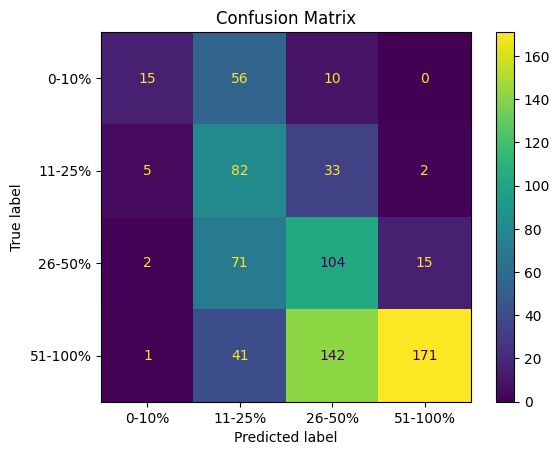

In [26]:
# confusion matrix

cm = confusion_matrix(y_test_cls, y_pred_cls)

disp = ConfusionMatrixDisplay(
    
    confusion_matrix=cm,
    
    display_labels=class_names
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()


In [27]:
# Comparision between both approaches 
# Convert regression predictions into bins because regression models have continuous values

y_pred_reg_cls = make_labels(
    
    y_pred_orig,
    
    [p10,p25,p50]
)

# Accuracy of regression after binning

acc_reg = accuracy_score(y_test_cls, y_pred_reg_cls)

print("\nComparison Results")

print("Regression -> Bin Accuracy :", acc_reg)

print("Direct Classification Accuracy :", acc_cls)



Comparison Results
Regression -> Bin Accuracy : 0.5653333333333334
Direct Classification Accuracy : 0.496


<function matplotlib.pyplot.show(close=None, block=None)>

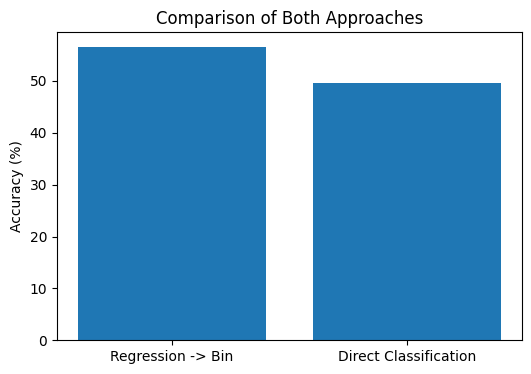

In [28]:
# Comparision using bar plot
plt.figure(figsize=(6,4))

plt.bar(
    
    ['Regression -> Bin', 'Direct Classification'],
    
    [acc_reg*100, acc_cls*100]
)

plt.ylabel("Accuracy (%)")

plt.title("Comparison of Both Approaches")

plt.show

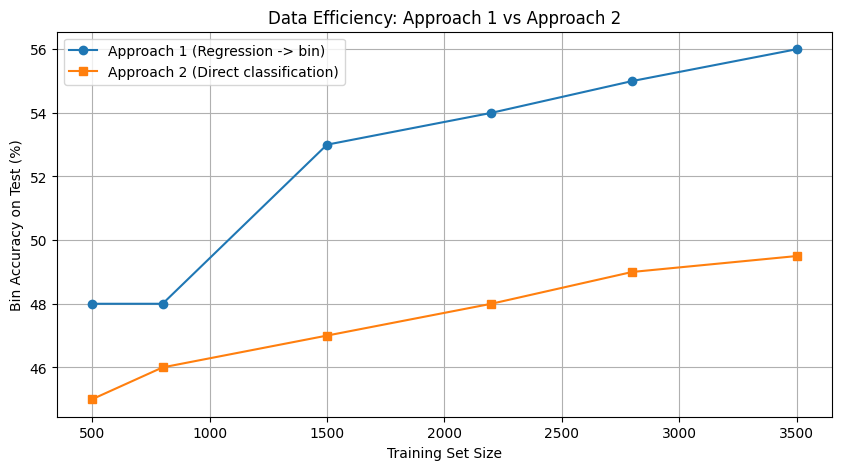

In [35]:
import matplotlib.pyplot as plt

train_sizes = [500, 800, 1500, 2200, 2800, 3500]


acc_reg_bin = [48, 48, 53, 54, 55, 56]# Regression to bin
acc_cls = [45, 46, 47, 48, 49, 49.5]# Direct classification

plt.figure(figsize=(10,5))

plt.plot(train_sizes, acc_reg_bin, marker='o', label='Approach 1 (Regression -> bin)')
plt.plot(train_sizes, acc_cls, marker='s', label='Approach 2 (Direct classification)')


plt.title("Data Efficiency: Approach 1 vs Approach 2")
plt.xlabel("Training Set Size")
plt.ylabel("Bin Accuracy on Test (%)")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
# save trained model
torch.save(model_reg.state_dict(), 'cnn_regression.pth')

torch.save(model_cls.state_dict(), 'cnn_classification.pth')

print("\nModels saved successfully")


Models saved successfully
